# 04 — Autoencoder

This notebook trains and evaluates an Autoencoder for credit card fraud detection using anomaly detection.

**Steps:**
1. Load processed data
2. Build and train the Autoencoder
3. Tune reconstruction error threshold
4. Evaluate on validation set
5. Final evaluation on test set
6. Save model and results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    f1_score
)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)

## 1. Load Data

The Autoencoder is trained only on legitimate transactions — it learns what normal behaviour looks like. Fraud detection happens at inference time based on reconstruction error.

In [2]:
# Load original (non-SMOTE) training set
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Train only on legitimate transactions
X_train_legit = X_train[y_train == 0]

print(f'Legitimate training samples: {X_train_legit.shape[0]}')
print(f'Val: {X_val.shape} | Test: {X_test.shape}')

Legitimate training samples: 398914
Val: (88581, 421) | Test: (88581, 421)


In [3]:
# Scale features — important for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_legit)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, '../results/ae_scaler.pkl')
print('Scaler fitted and saved.')

Scaler fitted and saved.


## 2. Build and Train the Autoencoder

The architecture compresses the input into a small bottleneck and then reconstructs it. Fraudulent transactions are expected to have higher reconstruction error since the model has only seen legitimate transactions.

In [4]:
input_dim = X_train_scaled.shape[1]

inputs = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(inputs)
encoded = Dense(64, activation='relu')(encoded)
bottleneck = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 421)]             0         
                                                                 
 dense (Dense)               (None, 128)               54016     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 64)                2112      
                                                                 
 dense_4 (Dense)             (None, 128)               8320      
                                                                 
 dense_5 (Dense)             (None, 421)               54309 

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/50
1403/1403 [==============================] - 6s 4ms/step - loss: 0.4033 - val_loss: 0.2900
Epoch 2/50
1403/1403 [==============================] - 5s 3ms/step - loss: 0.3022 - val_loss: 0.2535
Epoch 3/50
1403/1403 [==============================] - 5s 3ms/step - loss: 0.2869 - val_loss: 0.2347
Epoch 4/50
1403/1403 [==============================] - 5s 3ms/step - loss: 0.2600 - val_loss: 0.2475
Epoch 5/50
1403/1403 [==============================] - 5s 3ms/step - loss: 0.2407 - val_loss: 0.2202
Epoch 6/50
1403/1403 [==============================] - 5s 4ms/step - loss: 0.2217 - val_loss: 0.2286
Epoch 7/50
1403/1403 [==============================] - 5s 3ms/step - loss: 0.2209 - val_loss: 0.2138
Epoch 8/50
1403/1403 [==============================] - 5s 3ms/step - loss: 0.2759 - val_loss: 0.2405
Epoch 9/50
1403/1403 [==============================] - 5s 4ms/step - loss: 0.2338 - val_loss: 0.2023
Epoch 10/50
1403/1403 [==============================] - 5s 4ms/step - loss: 0.209

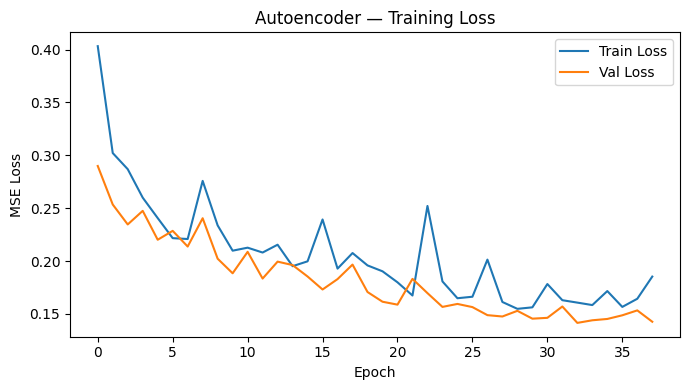

In [6]:
# Training loss curve
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder — Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/ae_training_loss.png', dpi=150)
plt.show()

## 3. Tune Reconstruction Error Threshold

The threshold determines when a transaction is classified as fraud. We tune it on the validation set by finding the value that maximises the F1-score for the fraud class.

In [7]:
# Get reconstruction errors on validation set
val_preds = autoencoder.predict(X_val_scaled)
val_errors = np.mean(np.power(X_val_scaled - val_preds, 2), axis=1)

# Try different thresholds and pick best F1
thresholds = np.percentile(val_errors, np.arange(80, 100, 0.5))
best_threshold = None
best_f1 = 0

for t in thresholds:
    y_pred = (val_errors > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f'Best threshold: {best_threshold:.6f}')
print(f'Best F1 on validation: {best_f1:.4f}')

2769/2769 [==============================] - 2s 630us/step
Best threshold: 0.583589
Best F1 on validation: 0.3049


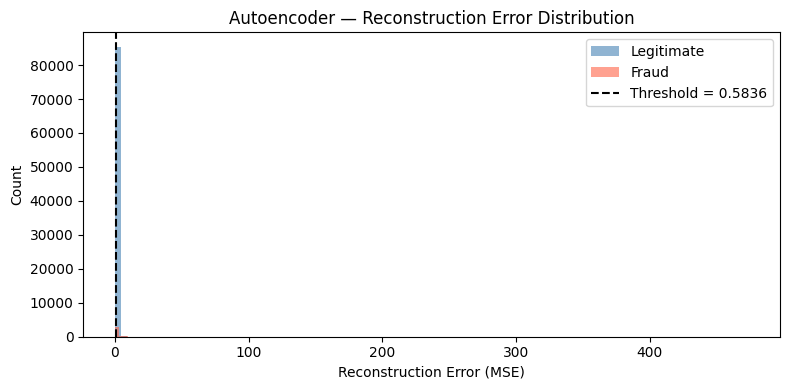

In [8]:
# Reconstruction error distribution
plt.figure(figsize=(8, 4))
plt.hist(val_errors[y_val == 0], bins=100, alpha=0.6, label='Legitimate', color='steelblue')
plt.hist(val_errors[y_val == 1], bins=100, alpha=0.6, label='Fraud', color='tomato')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold = {best_threshold:.4f}')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Autoencoder — Reconstruction Error Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/ae_reconstruction_error.png', dpi=150)
plt.show()

## 4. Validation Set Evaluation

In [9]:
y_pred_val = (val_errors > best_threshold).astype(int)

print('Autoencoder — Validation Set')
print(classification_report(y_val, y_pred_val))
print(f'ROC-AUC: {roc_auc_score(y_val, val_errors):.4f}')
print(f'PR-AUC:  {average_precision_score(y_val, val_errors):.4f}')

Autoencoder — Validation Set
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     85481
           1       0.29      0.33      0.30      3100

    accuracy                           0.95     88581
   macro avg       0.63      0.65      0.64     88581
weighted avg       0.95      0.95      0.95     88581

ROC-AUC: 0.7731
PR-AUC:  0.2368


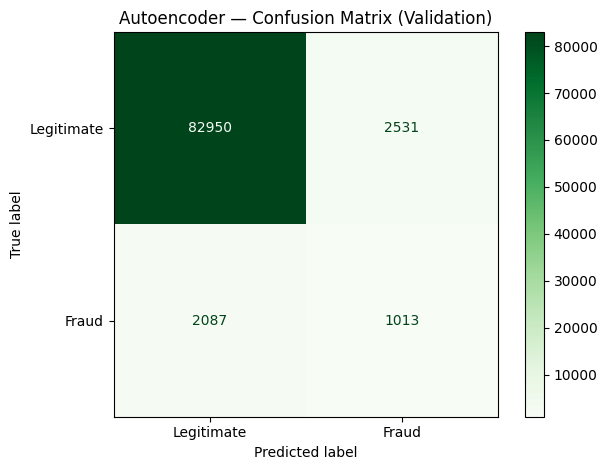

In [10]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Greens')
plt.title('Autoencoder — Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig('../results/figures/ae_confusion_matrix.png', dpi=150)
plt.show()

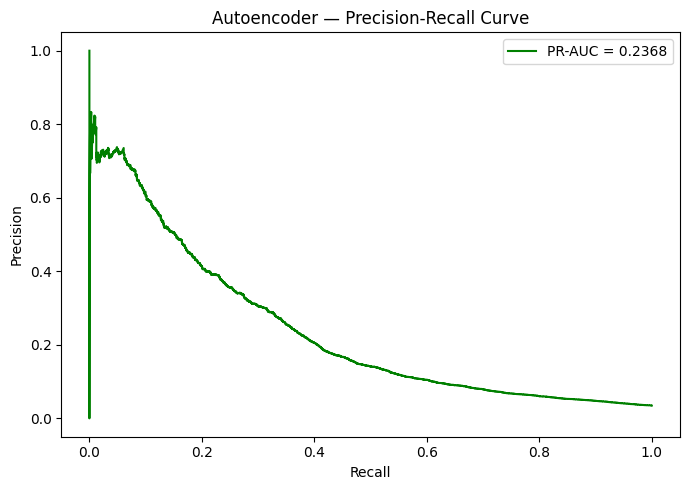

In [11]:
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val, val_errors)
pr_auc = average_precision_score(y_val, val_errors)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='green', label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Autoencoder — Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/ae_pr_curve.png', dpi=150)
plt.show()

## 5. Final Evaluation on Test Set

The threshold tuned on the validation set is applied to the test set.

In [12]:
test_preds = autoencoder.predict(X_test_scaled)
test_errors = np.mean(np.power(X_test_scaled - test_preds, 2), axis=1)

y_pred_test = (test_errors > best_threshold).astype(int)

print('Final Results — Test Set')
print(classification_report(y_test, y_pred_test))
print(f'ROC-AUC: {roc_auc_score(y_test, test_errors):.4f}')
print(f'PR-AUC:  {average_precision_score(y_test, test_errors):.4f}')

2769/2769 [==============================] - 2s 702us/step
Final Results — Test Set
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     85482
           1       0.28      0.33      0.30      3099

    accuracy                           0.95     88581
   macro avg       0.63      0.65      0.64     88581
weighted avg       0.95      0.95      0.95     88581

ROC-AUC: 0.7757
PR-AUC:  0.2351


In [13]:
# Inference latency
start = time.time()
autoencoder.predict(X_test_scaled, verbose=0)
elapsed = time.time() - start
latency_ms = (elapsed / len(X_test_scaled)) * 1000

print(f'Total inference time: {elapsed:.2f}s')
print(f'Average latency per transaction: {latency_ms:.4f} ms')

Total inference time: 2.23s
Average latency per transaction: 0.0251 ms


## 6. Save Model and Results

In [14]:
import os
os.makedirs('../results', exist_ok=True)

autoencoder.save('../results/ae_model.keras')
np.save('../results/ae_best_threshold.npy', best_threshold)
pd.Series(test_errors, name='ae_error').to_csv('../results/ae_test_errors.csv', index=False)

print('Model, threshold and predictions saved.')

Model, threshold and predictions saved.


## Summary

| Metric | Validation | Test |
|--------|-----------|------|
| PR-AUC | 0.2368 | 0.2351 |
| ROC-AUC | 0.7731 | 0.7757 |
| F1 (fraud) | 0.30 | 0.30 |
| Precision (fraud) | 0.29 | 0.28 |
| Recall (fraud) | 0.33 | 0.33 |
| Latency (ms/tx) | - | 0.0251 ms |

### Precision-Recall Curves Combined Graph

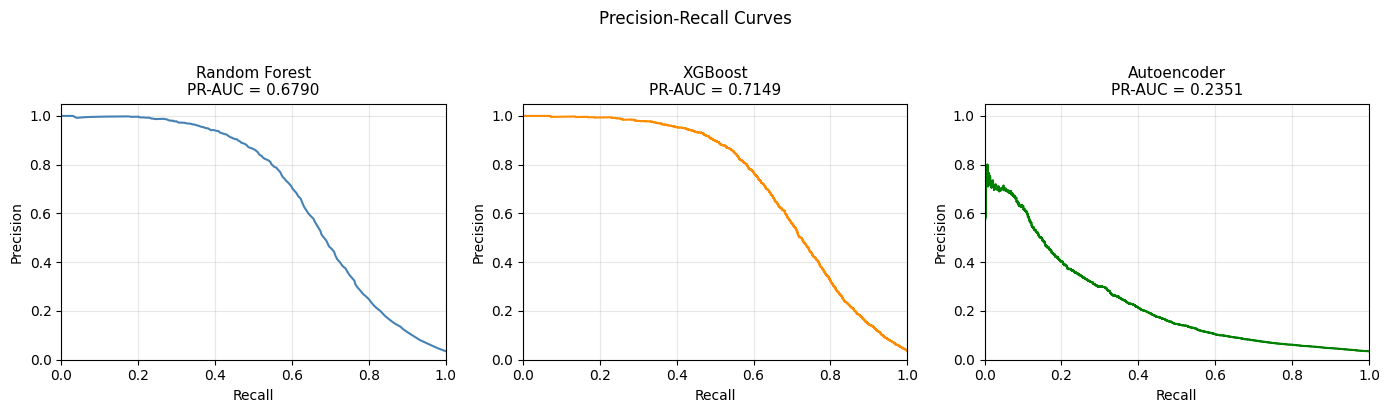

Saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_recall_curve, average_precision_score

# Load data and models
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
import tensorflow as tf

rf = joblib.load('../results/rf_model.pkl')
xgb = joblib.load('../results/xgb_model.pkl')
ae = tf.keras.models.load_model('../results/ae_model.keras')
scaler = joblib.load('../results/ae_scaler.pkl')
best_threshold = np.load('../results/ae_best_threshold.npy')

# Get probabilities
rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]
X_test_scaled = scaler.transform(X_test)
ae_recon = ae.predict(X_test_scaled, verbose=0)
ae_errors = np.mean(np.power(X_test_scaled - ae_recon, 2), axis=1)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models = [
    ('Random Forest', rf_prob, 'steelblue'),
    ('XGBoost', xgb_prob, 'darkorange'),
    ('Autoencoder', ae_errors, 'green'),
]

for ax, (name, scores, color) in zip(axes, models):
    p, r, _ = precision_recall_curve(y_test, scores)
    auc = average_precision_score(y_test, scores)
    ax.plot(r, p, color=color, linewidth=1.5)
    ax.set_title(f'{name}\nPR-AUC = {auc:.4f}', fontsize=11)
    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/pr_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')